In [1]:
import os
import sys
from sys import path
sys.path.append(os.path.expanduser('~/albatros_analysis'))
import numpy as np 
import numba as nb
import time
from scipy import linalg
from scipy import stats
from matplotlib import pyplot as plt
from datetime import datetime as dt
from src.correlations import baseband_data_classes as bdc
from src.utils import baseband_utils as butils
from src.utils import orbcomm_utils as outils
from scipy.optimize import least_squares
import json
#import extra_functions as ef
import random
#import h5py
from scripts.xcorr import helper as hp
import importlib
from scipy.interpolate import interp1d

BDC is using numpy
BDC is using numpy


In [2]:
files = butils.time2fnames(1753133403, 1753140603, '/scratch/mohanagr/summer_2025/baseband/mars1', 'f')

In [3]:
t1 = 11
t2 = 51
dt = 10

rounded = int(np.ceil((t2-t1)/dt))*dt + t1 +1
print(np.arange(t1, value, dt))


NameError: name 'value' is not defined

In [ ]:
for term in files:
    print(term)
    filename = os.path.basename(term)
    print(filename)
    tstamp_str = os.path.splitext(filename)[0]
    print(tstamp_str)
    timestamp = int(tstamp_str)
    print('done with one file')

/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753133413.raw
1753133413.raw
1753133413
done with one file
/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753133467.raw
1753133467.raw
1753133467
done with one file
/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753133521.raw
1753133521.raw
1753133521
done with one file
/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753133575.raw
1753133575.raw
1753133575
done with one file
/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753133628.raw
1753133628.raw
1753133628
done with one file
/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753133682.raw
1753133682.raw
1753133682
done with one file
/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753133737.raw
1753133737.raw
1753133737
done with one file
/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753133790.raw
1753133790.raw
1753133790
done with one file
/scratch/mohanagr/summer_2025/baseband/mars1/17531/1753133843.raw
1753133843.raw
1753133843
done with one file
/

507200
mars1
mars2
mars3
mars4
mars5
mars6
mars7
mars8
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


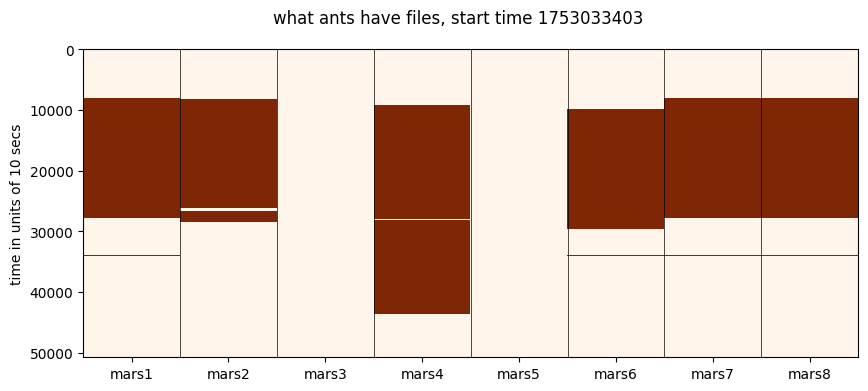

In [35]:
#setup/unpack
ant_path_list = ['/scratch/mohanagr/summer_2025/baseband/mars1', 
                 '/scratch/mohanagr/summer_2025/baseband/mars2', 
                 '/scratch/mohanagr/summer_2025/baseband/mars3',
                 '/scratch/mohanagr/summer_2025/baseband/mars4', 
                 '/scratch/mohanagr/summer_2025/baseband/mars5', 
                 '/scratch/mohanagr/summer_2025/baseband/mars6',
                 '/scratch/mohanagr/summer_2025/baseband/mars7', 
                 '/scratch/mohanagr/summer_2025/baseband/mars8']
ant2files = {}
time_start = 1753033403
time_end = 1753540603
print(time_end - time_start)
tolerance = 30
T_SCAN = 10

ant_name_list = []
for ant_path in ant_path_list:
    path_name = os.path.basename(ant_path)
    ant_name = os.path.splitext(path_name)[0]
    print(ant_name)
    ant_name_list.append(ant_name)

for ant_idx, ant_path in enumerate(ant_path_list):
    ant_name = ant_name_list[ant_idx]
    files_raw = []
    tstamps = []
    try:
        files_raw = butils.time2fnames(time_start, time_end, ant_path, 'f')
    except FileNotFoundError:
        files_raw = []

    for file in files_raw:
        filename = os.path.basename(file)
        tstamp_str = os.path.splitext(filename)[0]
        tstamp = int(tstamp_str)
        tstamps.append(tstamp)
    
    tstamps = np.array(tstamps)
    ant2files[ant_name] = tstamps

rounded = int(np.ceil((time_end-time_start)/T_SCAN))*T_SCAN + time_start +1 #round UP to the nearest dt.
times = np.arange(time_start, rounded, T_SCAN)
arr = np.zeros((len(times), len(ant_name_list)))
for t_idx, time in enumerate(times):
    for ant_idx, ant_name in enumerate(ant_name_list):
        data = ant2files[ant_name]
        if np.any(np.abs(data - time) <= tolerance):
            arr[t_idx][ant_idx] = 1

print(arr)
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle(f"what ants have files, start time {time_start}")

ax.set_ylabel(f"time in units of {T_SCAN} secs")

im = ax.imshow(arr, aspect='auto', interpolation='none', cmap='Oranges')

ax.set_xticks(range(len(ant_name_list)))
ax.set_xticklabels(ant_name_list)

for x in range(1, arr.shape[1]):
    ax.axvline(x - 0.5, color='black', linewidth=0.5)

plt.show()

In [ ]:
def check_for_data(t_start, t_end, path_list, T_SCAN = 10, tolerance = 60):

    for ant_idx, ant_path in enumerate(ant_list):
        files_raw = []
        tstamps = []
        try:
            files_raw = butils.time2fnames(time_start, time_end, ant_path, 'f')
        except FileNotFoundError:
            files_raw = []

        for file in files_raw:
            filename = os.path.basename(file)
            tstamp_str = os.path.splitext(filename)[0]
            tstamp = int(tstamp_str)
            tstamps.append(tstamp)
        
        tstamps = np.array(tstamps)
        ant2files[ant_path] = tstamps

    rounded = int(np.ceil((time_end-time_start)/T_SCAN))*T_SCAN + time_start +1 #round UP to the nearest dt.
    times = np.arange(time_start, rounded, dt)
    arr = np.zeros((len(times), len(ant_list)))
    for t_idx, time in enumerate(times):
        for ant_idx, ant_name in enumerate(ant_list):
            data = ant2files[ant_name]
            if np.any(np.abs(data - time) <= tolerance):
                arr[t_idx][ant_idx] = 1
                
    return arr


In [ ]:

def get_risen_sats(tle_file, coords, t_start, dt=None, niter=560, good=None,altitude_cutoff=1):
    """Get all satellites risen at a particular point on earth at a list of epochs.
    Epochs start at t_start and a list of risen satellites is returned for every t_start + i * dt epoch
    The satellites are read form a TLE file (currently hardcoded).

    Parameters
    ----------
    coords : tuple of floats
        (latitude, longitude, elevation) of the position on Earth. Elevation is measured in meteres.
    t_start : float
        Start timestamp (ctime). Converted to JD internally.
    dt : float, optional
        Delta between epochs, by default None which sets it to 6.44 seconds internally (accumulation time of direct spectra).
    niter : int, optional
        Number of iterations, by default 560
    elevation_cutoff : float, optional
        Altitude cutoff (in degrees) above which a satellite is considered risen, by default 1 degree.

    Returns
    -------
    risen_sats : list of lists
        One list of risen satellites per epoch. Each epoch's list carries the name of the risen satellite at that epoch.
        E.g. [["FM118","NOAA15"], ["NOAA15"]]
    """
    junk = [11060, 
            35865, #Meteor M-1
            14154, #HILAT
            28650,  #HAMSAT, old Indian sat
            28371, #Saudi sat 2
            5580 #PROSPERO
            ]
    if not good:
        good=[28654,25338,33591,57166,59051,44387]
    obs1 = sf.wgs84.latlon(*coords)
    sats = sf.load.tle_file(tle_file)
    tt = t_start
    ts = sf.load.timescale()
    if not dt:
        dt = 393216 * 4096 / 250e6
    print("Starting Time of", tt, "with a dt of", dt)
    risen_sats = []
    for iter in range(niter):
        visible = []
        alt_count = 0
        jd = ctime2mjd(tt, type="JD")
        t = ts.ut1_jd(jd)

        for sat in sats:
            # if sat.model.satnum in junk: continue
            if sat.model.satnum not in good: continue
            # if (
            # "[+]" not in sat.name and "NOAA" not in sat.name
            # ):  # extracting operational ORBCOMM ([+]) and NOAA from TLE file
            # continue
            diff = sat - obs1
            topocentric = diff.at(t)
            alt, az, dist = topocentric.altaz()
            # print(sat.name)
            if alt.degrees > altitude_cutoff:
                # print(alt.degrees, az.degrees)
                # if sat.name is None:
                #     sat.name =
                visible.append([sat.model.satnum, alt.degrees, az.degrees])
        #         if(alt_count in (1,)):
        #             print(iter,'have ',alt_count,' in beam -6 dB range', visible)
        risen_sats.append(visible)
        tt += dt
    return risen_sats